In [2]:
#install if needed
!pip install pretty_midi

     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     - -------------------------------------- 0.3/5.6 MB ? eta -:--:--
     - -------------------------------------- 0.3/5.6 MB ? eta -:--:--
     - -------------------------------------- 0.3/5.6 MB ? eta -:--:--
     --- ------------------------------------ 0.5/5.6 MB 364.6 kB/s eta 0:00:14
     --- ------------------------------------ 0.5/5.6 MB 364.6 kB/s eta 0:00:14
     ----- ---------------------------------- 0.8/5.6 MB 447.3 kB/s eta 0:00:11
     ----- ---------------------------------- 0.8/5.6 MB 447.3 kB/s eta 0:00:11
     ------- -------------------------------- 1.0/5.6 MB 503.2 kB/s eta 0:00:10
     ------- -------------------------------- 1.0/5.6 MB 503.2 kB/s eta 0:00:10
     --------- --------

In [24]:
# This notebook is using Python ver. 3.10

import torch # main lib
import torch.nn as nn # neural network
import torch.optim as optim # optimization
from sklearn.datasets import load_breast_cancer # dataset
from sklearn.preprocessing import StandardScaler # scaler
from sklearn.model_selection import train_test_split

import pretty_midi
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import numpy as np


# added because some midi files are generated correctly
import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="pretty_midi"
)

In [4]:
def safe_stat(values, statistic="mean", default=0.0):
    """
    Safely calculate a statistic from a list or NumPy array.
    """
    values = np.asarray(values, dtype=float)

    if values.size == 0:
        return default

    if statistic == "mean":
        return float(np.mean(values))
    elif statistic == "std":
        return float(np.std(values))
    elif statistic == "min":
        return float(np.min(values))
    elif statistic == "max":
        return float(np.max(values))
    elif statistic == "median":
        return float(np.median(values))

    raise ValueError(f"Unsupported statistic: {statistic}")

In [5]:
def extract_midi_features(file_path):
    """
    Extract file-level musical features from one MIDI file.
    """
    try:
        midi = pretty_midi.PrettyMIDI(str(file_path))
    except Exception as error:
        print(f"Could not read {file_path}: {error}")
        return None

    pitches = []
    velocities = []
    durations = []
    start_times = []
    pitch_classes = []
    intervals = []

    instrument_programs = []
    melodic_track_count = 0
    drum_track_count = 0

    for instrument in midi.instruments:
        instrument_programs.append(instrument.program)

        if instrument.is_drum:
            drum_track_count += 1
        else:
            melodic_track_count += 1

        instrument_notes = sorted(
            instrument.notes,
            key=lambda note: note.start
        )

        previous_pitch = None

        for note in instrument_notes:
            duration = max(0.0, note.end - note.start)

            pitches.append(note.pitch)
            velocities.append(note.velocity)
            durations.append(duration)
            start_times.append(note.start)
            pitch_classes.append(note.pitch % 12)

            if previous_pitch is not None:
                intervals.append(abs(note.pitch - previous_pitch))

            previous_pitch = note.pitch

    if len(pitches) == 0:
        return None

    # Estimate tempo.
    try:
        tempo = float(midi.estimate_tempo())
    except Exception:
        tempo = 0.0

    # MIDI duration in seconds.
    total_duration = float(midi.get_end_time())

    # Number of notes per second.
    note_density = (
        len(pitches) / total_duration
        if total_duration > 0
        else 0.0
    )

    # Pitch range.
    pitch_range = max(pitches) - min(pitches)

    # Pitch-class distribution: C, C#, D, ..., B.
    pitch_class_counts = Counter(pitch_classes)
    pitch_class_total = max(1, len(pitch_classes))

    pitch_class_features = {
        f"pitch_class_{pitch_class}":
            pitch_class_counts.get(pitch_class, 0) / pitch_class_total
        for pitch_class in range(12)
    }

    # Percentage of notes that overlap another note.
    sorted_notes = []

    for instrument in midi.instruments:
        if instrument.is_drum:
            continue

        sorted_notes.extend(instrument.notes)

    sorted_notes = sorted(sorted_notes, key=lambda note: note.start)

    overlapping_notes = 0
    previous_end = -np.inf

    for note in sorted_notes:
        if note.start < previous_end:
            overlapping_notes += 1

        previous_end = max(previous_end, note.end)

    polyphony_rate = (
        overlapping_notes / len(sorted_notes)
        if len(sorted_notes) > 0
        else 0.0
    )

    # Time-signature information.
    time_signatures = midi.time_signature_changes

    if time_signatures:
        first_numerator = time_signatures[0].numerator
        first_denominator = time_signatures[0].denominator
    else:
        first_numerator = 0
        first_denominator = 0

    # Key signature information.
    key_changes = midi.key_signature_changes

    if key_changes:
        first_key_number = key_changes[0].key_number
        number_of_key_changes = len(key_changes)
    else:
        first_key_number = -1
        number_of_key_changes = 0

    features = {
        "file_name": Path(file_path).name,

        "tempo": tempo,
        "total_duration": total_duration,
        "number_of_tracks": len(midi.instruments),
        "melodic_track_count": melodic_track_count,
        "drum_track_count": drum_track_count,
        "unique_instruments": len(set(instrument_programs)),

        "number_of_notes": len(pitches),
        "note_density": note_density,

        "pitch_mean": safe_stat(pitches, "mean"),
        "pitch_std": safe_stat(pitches, "std"),
        "pitch_min": safe_stat(pitches, "min"),
        "pitch_max": safe_stat(pitches, "max"),
        "pitch_range": float(pitch_range),

        "velocity_mean": safe_stat(velocities, "mean"),
        "velocity_std": safe_stat(velocities, "std"),
        "velocity_min": safe_stat(velocities, "min"),
        "velocity_max": safe_stat(velocities, "max"),

        "duration_mean": safe_stat(durations, "mean"),
        "duration_std": safe_stat(durations, "std"),
        "duration_median": safe_stat(durations, "median"),
        "duration_min": safe_stat(durations, "min"),
        "duration_max": safe_stat(durations, "max"),

        "interval_mean": safe_stat(intervals, "mean"),
        "interval_std": safe_stat(intervals, "std"),
        "interval_max": safe_stat(intervals, "max"),

        "polyphony_rate": polyphony_rate,

        "time_signature_numerator": first_numerator,
        "time_signature_denominator": first_denominator,
        "first_key_number": first_key_number,
        "number_of_key_changes": number_of_key_changes,
        "number_of_tempo_changes": len(midi.get_tempo_changes()[0]),
    }

    features.update(pitch_class_features)

    return features

In [17]:
def build_midi_dataset(dataset_directory):
    """
    Create a DataFrame by recursively searching each artist folder
    for MIDI files.

    Expected structure:

    midi_dataset/
    ├── artist_1/
    │   ├── song_1.mid
    │   ├── album_1/
    │   │   ├── song_2.mid
    │   │   └── song_3.midi
    │   └── album_2/
    │       └── song_4.mid
    ├── artist_2/
    ├── artist_3/
    └── artist_4/
    """

    dataset_directory = Path(dataset_directory)

    if not dataset_directory.exists():
        raise FileNotFoundError(
            f"Dataset directory does not exist: {dataset_directory}"
        )

    if not dataset_directory.is_dir():
        raise NotADirectoryError(
            f"The provided path is not a directory: {dataset_directory}"
        )

    rows = []

    # Each top-level folder represents one artist.
    artist_folders = sorted(
        folder
        for folder in dataset_directory.iterdir()
        if folder.is_dir() and not folder.name.startswith(".")
    )

    if not artist_folders:
        raise ValueError(
            "No artist folders were found in the dataset directory."
        )

    for artist_folder in artist_folders:
        artist_name = artist_folder.name

        # Recursively search the artist folder and all subfolders.
        midi_files = sorted(
            file
            for file in artist_folder.rglob("*")
            if file.is_file()
            and file.suffix.lower() in {".mid", ".midi"}
        )

        print(
            f"Found {len(midi_files)} MIDI files "
            f"for artist: {artist_name}"
        )

        if not midi_files:
            print(
                f"Warning: No MIDI files found inside "
                f"{artist_folder}"
            )
            continue

        for midi_file in midi_files:
            features = extract_midi_features(midi_file)

            if features is None:
                print(f"Skipped unreadable file: {midi_file}")
                continue

            features["artist"] = artist_name
            features["file_name"] = midi_file.name
            features["file_path"] = str(midi_file)

            # Shows where the file is located relative to the artist folder.
            features["relative_path"] = str(
                midi_file.relative_to(artist_folder)
            )

            # Store the immediate parent folder, such as an album folder.
            features["parent_folder"] = midi_file.parent.name

            rows.append(features)

    dataset = pd.DataFrame(rows)

    if dataset.empty:
        raise ValueError(
            "No valid MIDI files were successfully processed."
        )

    print(f"\nSuccessfully processed {len(dataset)} MIDI files.")

    return dataset

In [18]:
# Change directory to location off midi files
DATASET_DIRECTORY = "./datasets"

midi_df = build_midi_dataset(DATASET_DIRECTORY)

print("Dataset shape:", midi_df.shape)

midi_df[
    [
        "artist",
        "file_name",
        "parent_folder",
        "relative_path"
    ]
].head(10)

Found 1024 MIDI files for artist: Bach


C:\Users\Nick\miniconda3\envs\py310\lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Found 213 MIDI files for artist: Beethoven
Could not read datasets\Beethoven\Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Skipped unreadable file: datasets\Beethoven\Anhang 14-3.mid
Found 136 MIDI files for artist: Chopin
Found 257 MIDI files for artist: Mozart
Could not read datasets\Mozart\Piano Sonatas\Nueva carpeta\K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2
Skipped unreadable file: datasets\Mozart\Piano Sonatas\Nueva carpeta\K281 Piano Sonata n03 3mov.mid

Successfully processed 1628 MIDI files.
Dataset shape: (1628, 48)


,artist,file_name,parent_folder,relative_path
0,Bach,AveMaria.mid,Bach,AveMaria.mid
1,Bach,01 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
2,Bach,02 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
3,Bach,03 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
4,Bach,04 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
5,Bach,05 Polonaise.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
6,Bach,06 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
7,Bach,07 Rondo.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
8,Bach,08 Polonaise.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...
9,Bach,09 Menuet.mid,Bwv ''Little Notebook for Anna Magdalena Bach'',Bwv ''Little Notebook for Anna Magdalena Bach'...


In [20]:
# save midi features locally as csv
midi_df.to_csv("midi_artist_features.csv", index=False)

artist
Bach         1024
Mozart        256
Beethoven     212
Chopin        136
Name: count, dtype: int64


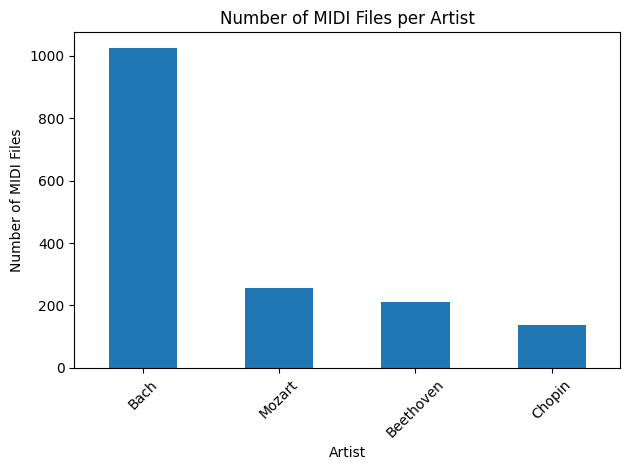

In [25]:
artist_counts = midi_df["artist"].value_counts()

print(artist_counts)

artist_counts.plot(
    kind="bar",
    title="Number of MIDI Files per Artist"
)

plt.xlabel("Artist")
plt.ylabel("Number of MIDI Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
metadata_columns = [
    "file_name",
    "file_path",
    "artist"
]

feature_columns = [
    column
    for column in midi_df.columns
    if column not in metadata_columns
]

X = midi_df[feature_columns].copy()
y = midi_df["artist"].copy()

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 45
['tempo', 'total_duration', 'number_of_tracks', 'melodic_track_count', 'drum_track_count', 'unique_instruments', 'number_of_notes', 'note_density', 'pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_range', 'velocity_mean', 'velocity_std', 'velocity_min', 'velocity_max', 'duration_mean', 'duration_std', 'duration_median', 'duration_min', 'duration_max', 'interval_mean', 'interval_std', 'interval_max', 'polyphony_rate', 'time_signature_numerator', 'time_signature_denominator', 'first_key_number', 'number_of_key_changes', 'number_of_tempo_changes', 'pitch_class_0', 'pitch_class_1', 'pitch_class_2', 'pitch_class_3', 'pitch_class_4', 'pitch_class_5', 'pitch_class_6', 'pitch_class_7', 'pitch_class_8', 'pitch_class_9', 'pitch_class_10', 'pitch_class_11', 'relative_path', 'parent_folder']


In [32]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Artist classes:", label_encoder.classes_)

Artist classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1302
Testing samples: 326


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Support Vector Machine": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

In [40]:
model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    model_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    trained_models[model_name] = model

    print("=" * 70)
    print(model_name)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'Etude No.1.mid'